# CS3621 Data Mining · Time Series companion notebook

This notebook reproduces every computation behind the two Time Series lectures, in the
same order as the slides. Run it top to bottom; each section is self-contained after the
setup cell.

| Section | Lecture | Slides |
|---|---|---|
| 0. Setup and data | both | |
| 1. Order is the information | 1 | 6 to 9 |
| 2. Components and decomposition | 1 | 14 to 31 |
| 3. Frequency: periodogram and spectrogram | 1 | 22, 34 |
| 4. Anomalies in the remainder | 1 | 35 to 38 |
| 5. Stationarity and the treatment pipeline | 1 | 39 to 51 |
| 6. ACF, PACF and model signatures | 2 | 4 to 8 |
| 7. Benchmarks and exponential smoothing | 2 | 11 to 14 |
| 8. SARIMA, diagnostics, evaluation | 2 | 15 to 26 |
| 9. Similarity: z-normalisation and DTW | 2 | 32 to 38 |
| 10. Motifs, discords and the matrix profile | 2 | 39 to 46 |

**Requirements:** `numpy pandas matplotlib scipy statsmodels`. Everything else is optional
and the notebook falls back gracefully if it is missing.

```
pip install numpy pandas matplotlib scipy statsmodels
```

In [1]:
# ---- Section 0: setup -------------------------------------------------------
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (11, 3.4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": .35, "font.size": 10,
})
INK, BLUE, ORANGE, TEAL, RED, GREEN, PURPLE = (
    "#14213D", "#2563EB", "#F97316", "#0D9488", "#DC2626", "#16A34A", "#7C3AED")

RNG = np.random.default_rng(7)
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.5.2 | pandas 3.0.5


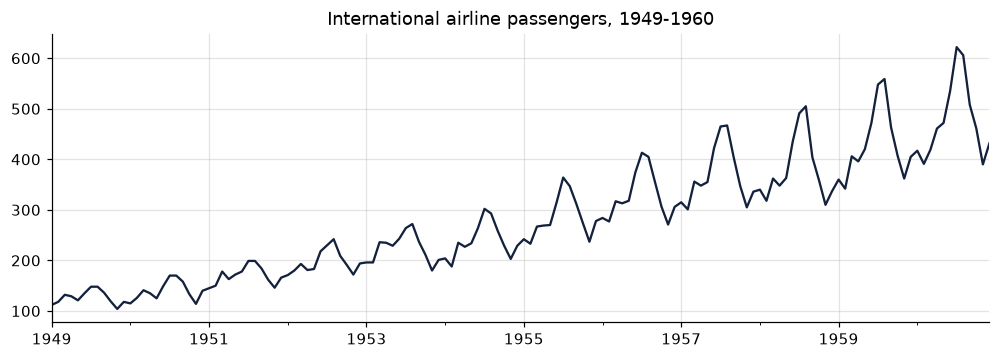

In [2]:
# ---- The running example: Box & Jenkins airline passengers ------------------
# Monthly totals, thousands, Jan 1949 to Dec 1960. Embedded so the notebook works offline.
AIR = np.array([
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432], dtype=float)

air = pd.Series(AIR, index=pd.period_range("1949-01", periods=144, freq="M").to_timestamp(),
                name="passengers")
air.index.freq = "MS"
air.plot(color=INK, title="International airline passengers, 1949-1960");

---
## 1. Order is the information  ·  Lecture 1, slides 6 to 9

### 1.1 The shuffle test

Keep every value, destroy only the ordering. The two histograms are identical, so **no
summary statistic can tell these two datasets apart** even though one is useful and the
other is not.

mean      280.299  vs 280.299
std       119.966  vs 119.549
identical multiset of values: True


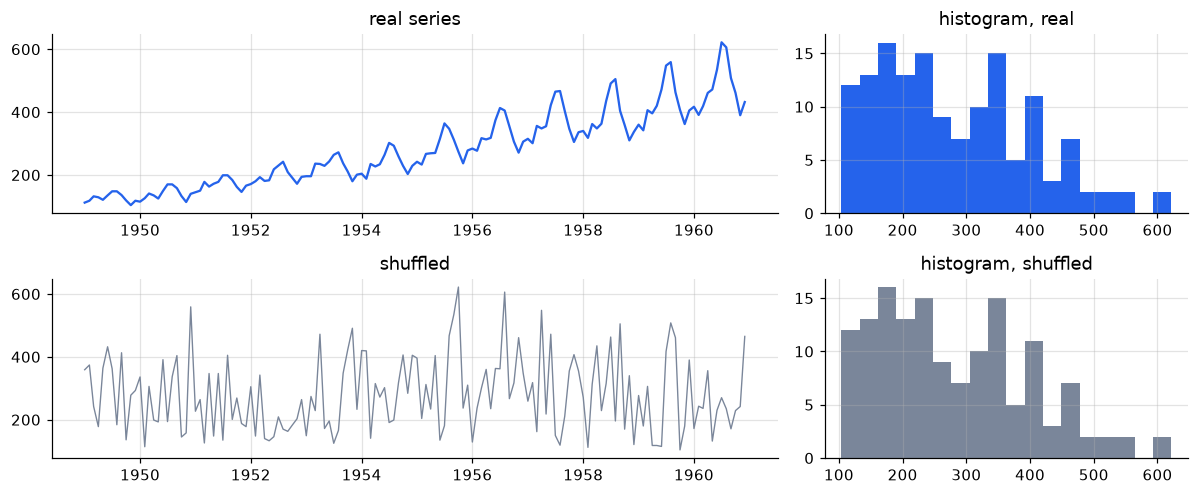

In [3]:
shuffled = air.values.copy()
np.random.default_rng(1).shuffle(shuffled)

fig, ax = plt.subplots(2, 2, figsize=(11, 4.6),
                       gridspec_kw=dict(width_ratios=[2, 1]))
ax[0,0].plot(air.index, air.values, color=BLUE);      ax[0,0].set_title("real series")
ax[1,0].plot(air.index, shuffled, color="#7A869A", lw=.9); ax[1,0].set_title("shuffled")
ax[0,1].hist(air.values, bins=18, color=BLUE);        ax[0,1].set_title("histogram, real")
ax[1,1].hist(shuffled,   bins=18, color="#7A869A");   ax[1,1].set_title("histogram, shuffled")
plt.tight_layout()

print("mean      %.3f  vs %.3f" % (air.mean(), shuffled.mean()))
print("std       %.3f  vs %.3f" % (air.std(),  shuffled.std()))
print("identical multiset of values:", np.array_equal(np.sort(air.values), np.sort(shuffled)))

### 1.2 Autocorrelation is correlation with a shifted copy

Nothing more mysterious than that. Try changing `lag` and watch the cloud flatten.

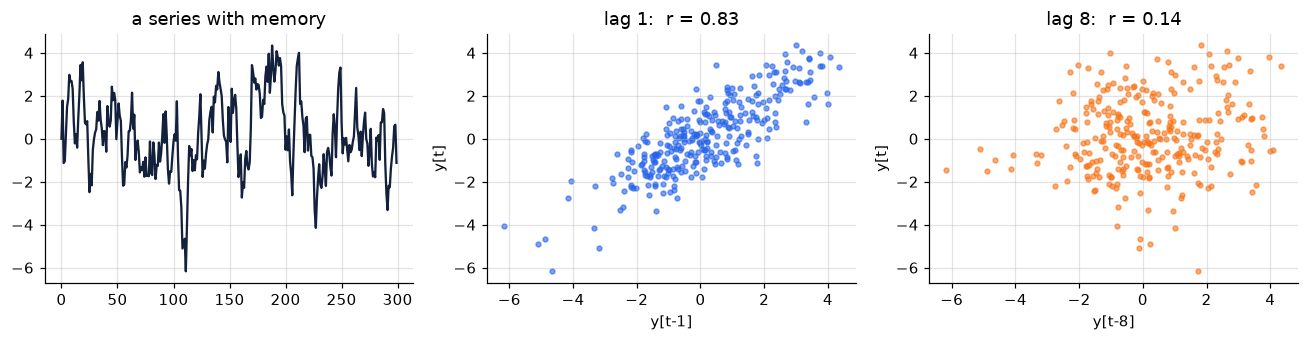

In [4]:
def acf(x, nlags):
    "Sample autocorrelation, lags 0..nlags."
    x = np.asarray(x, float) - np.mean(x)
    d = (x ** 2).sum()
    return np.array([1.0] + [(x[k:] * x[:-k]).sum() / d for k in range(1, nlags + 1)])


def ar1(n=300, phi=.8, seed=6):
    e = np.random.default_rng(seed).normal(0, 1, n)
    x = np.zeros(n)
    for i in range(1, n):
        x[i] = phi * x[i-1] + e[i]
    return x

y = ar1()
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))
ax[0].plot(y, color=INK); ax[0].set_title("a series with memory")
for a, lag, c in [(ax[1], 1, BLUE), (ax[2], 8, ORANGE)]:
    a.scatter(y[:-lag], y[lag:], s=10, color=c, alpha=.6)
    a.set_title(f"lag {lag}:  r = {np.corrcoef(y[:-lag], y[lag:])[0,1]:.2f}")
    a.set_xlabel(f"y[t-{lag}]"); a.set_ylabel("y[t]")
plt.tight_layout()

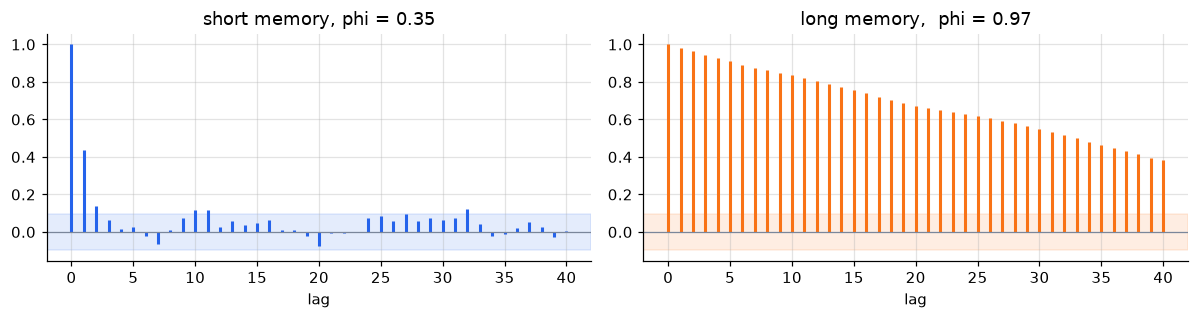

In [5]:
def plot_acf(r, n, ax=None, color=BLUE, title=""):
    ax = ax or plt.gca()
    ci = 1.96 / np.sqrt(n)
    ax.axhspan(-ci, ci, color=color, alpha=.12)
    ax.vlines(np.arange(len(r)), 0, r, color=color, lw=2)
    ax.axhline(0, color="#7A869A", lw=.8)
    ax.set_title(title); ax.set_xlabel("lag")
    return ax

fig, ax = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(acf(ar1(400, .35, 21), 40), 400, ax[0], BLUE,   "short memory, phi = 0.35")
plot_acf(acf(ar1(400, .97, 21), 40), 400, ax[1], ORANGE, "long memory,  phi = 0.97")
plt.tight_layout()
# The slowly decaying ACF on the right is also the classic non-stationarity fingerprint.

---
## 2. Components and decomposition  ·  Lecture 1, slides 14 to 31

### 2.1 Build a series from its parts

Decomposition is this cell run backwards: you are given only the bottom panel.

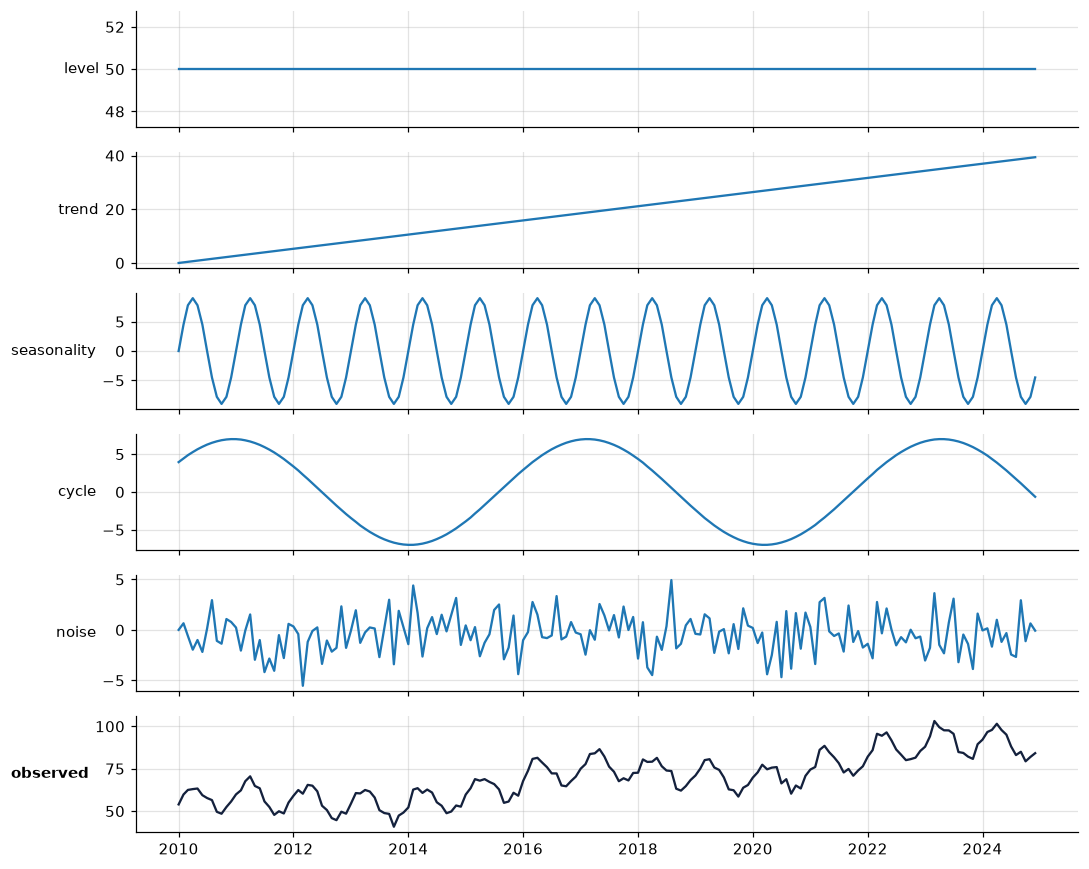

In [6]:
n = 180; t = np.arange(n)
idx = pd.period_range("2010-01", periods=n, freq="M").to_timestamp()
parts = {
    "level":       np.full(n, 50.0),
    "trend":       0.22 * t,
    "seasonality": 9 * np.sin(2*np.pi*t/12),
    "cycle":       7 * np.sin(2*np.pi*t/74 + .6),
    "noise":       RNG.normal(0, 2.2, n),
}
fig, ax = plt.subplots(6, 1, figsize=(10, 8), sharex=True)
for a, (k, v) in zip(ax, parts.items()):
    a.plot(idx, v); a.set_ylabel(k, rotation=0, ha="right", va="center")
ax[5].plot(idx, sum(parts.values()), color=INK)
ax[5].set_ylabel("observed", rotation=0, ha="right", va="center", fontweight="bold")
plt.tight_layout()

### 2.2 Additive or multiplicative, and why the log matters

The airline series is multiplicative: the seasonal swing grows with the level. Taking logs
turns it into an additive problem **and** stabilises the variance at the same time.

In [7]:
def swing_ratio(x, k=36):
    "Ratio of the late peak-to-trough swing to the early one."
    return np.ptp(x[-k:]) / np.ptp(x[:k])

from scipy.stats import boxcox
bc, lam = boxcox(air.values)
for name, v in [("raw", air.values), ("sqrt", np.sqrt(air.values)),
                ("log", np.log(air.values)), (f"box-cox (lam={lam:.3f})", bc)]:
    print(f"{name:24s} late:early swing = 1 : {swing_ratio(v):.2f}")

raw                      late:early swing = 1 : 3.28
sqrt                     late:early swing = 1 : 1.88
log                      late:early swing = 1 : 1.07
box-cox (lam=0.148)      late:early swing = 1 : 1.27


### 2.3 STL

`period` is the seasonal length. `robust=True` down-weights outliers so one strange month
cannot bend the trend. STL will **not** find the period for you: that is section 3.

remainder std as % of series std: 5.8%


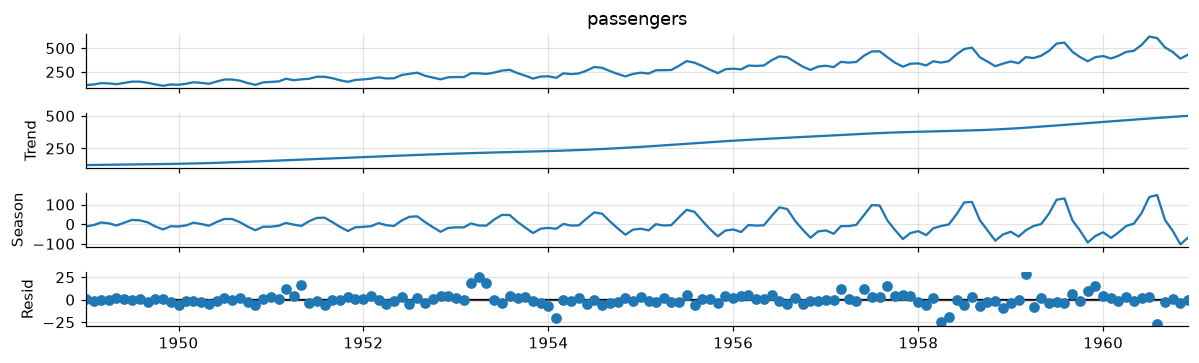

In [8]:
from statsmodels.tsa.seasonal import STL

res = STL(air, period=12, robust=True).fit()
res.plot(); plt.tight_layout()

seasonally_adjusted = air - res.seasonal
print("remainder std as %% of series std: %.1f%%"
      % (100 * res.resid.std() / air.std()))

### 2.4 Judge any decomposition by its remainder

Four checks: no pattern in time, ACF inside the band, roughly symmetric around zero, and
constant variance. Compare a good residual series with a bad one.

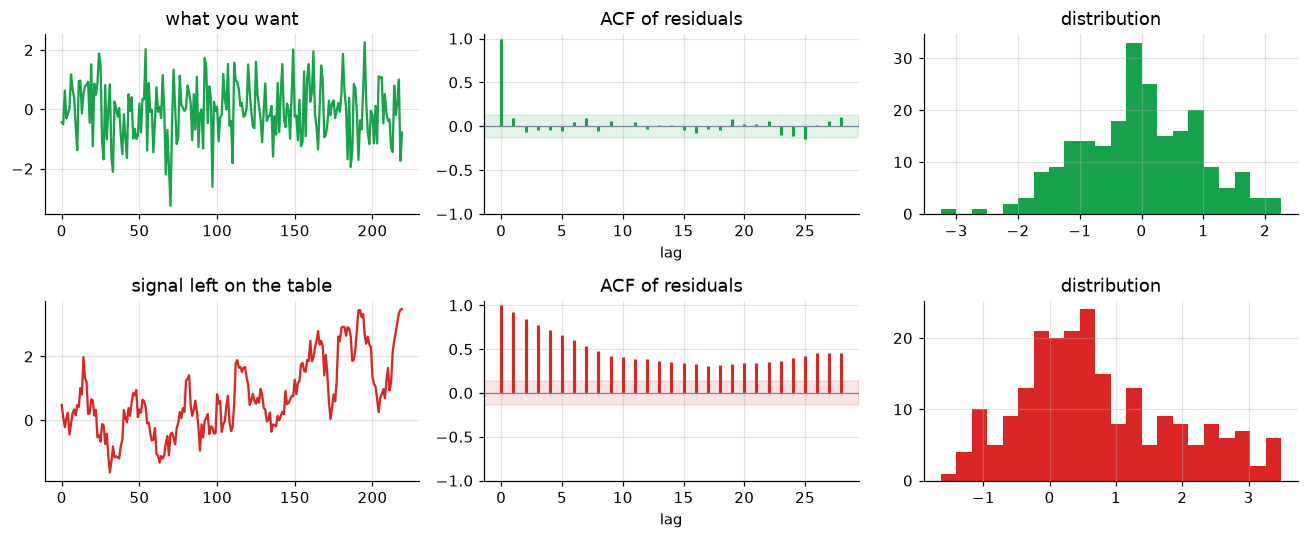

In [9]:
good = RNG.normal(0, 1, 220)
bad  = np.convolve(RNG.normal(0, 1, 240), np.ones(9)/9, "same")[:220] * 3 + .012*np.arange(220)

fig, ax = plt.subplots(2, 3, figsize=(12, 5))
for row, (v, lab, c) in enumerate([(good, "what you want", GREEN),
                                   (bad,  "signal left on the table", RED)]):
    ax[row,0].plot(v, color=c); ax[row,0].set_title(lab)
    plot_acf(acf(v, 28), len(v), ax[row,1], c, "ACF of residuals")
    ax[row,1].set_ylim(-1, 1.05)
    ax[row,2].hist(v, bins=22, color=c); ax[row,2].set_title("distribution")
plt.tight_layout()

### 2.5 The seasonal subseries plot

All the Januaries, then all the Februaries. One picture gives you the seasonal shape, the
trend inside each month, and whether the seasonal amplitude is growing.

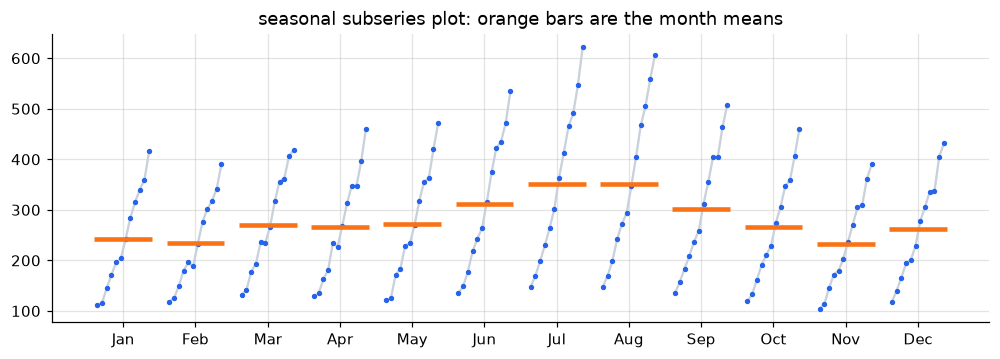

In [10]:
df = pd.DataFrame({"v": air.values, "m": air.index.month})
fig, ax = plt.subplots(figsize=(11, 3.4))
for i, m in enumerate(range(1, 13)):
    sub = df.loc[df.m == m, "v"].values
    xs = i + np.linspace(-.36, .36, len(sub))
    ax.plot(xs, sub, color="#C9D1DC"); ax.plot(xs, sub, "o", ms=2.5, color=BLUE)
    ax.hlines(sub.mean(), i-.4, i+.4, color=ORANGE, lw=3)
ax.set_xticks(range(12))
ax.set_xticklabels("Jan Feb Mar Apr May Jun Jul Aug Sep Oct Nov Dec".split())
ax.set_title("seasonal subseries plot: orange bars are the month means");

---
## 3. Frequency  ·  Lecture 1, slides 22 and 34

### 3.1 The periodogram finds periods you did not know about

Two rhythms are buried in noise. The FFT separates them. **Always de-trend first**: a trend
dumps enormous energy at low frequencies and drowns everything else.

strongest periods: [24.4  7.  23.3 25.6]


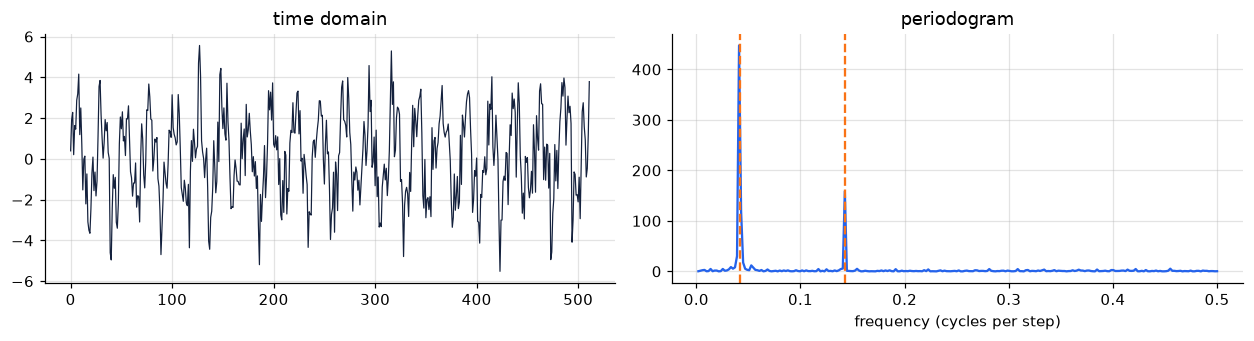

In [11]:
n = 512; t = np.arange(n)
y = (2.2*np.sin(2*np.pi*t/24) + 1.1*np.sin(2*np.pi*t/7 + .8)
     + np.random.default_rng(31).normal(0, 1, n))

power = np.abs(np.fft.rfft(y - y.mean()))**2 / n
freq  = np.fft.rfftfreq(n, 1.0)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.2))
ax[0].plot(t, y, color=INK, lw=.8); ax[0].set_title("time domain")
ax[1].plot(freq[1:], power[1:], color=BLUE); ax[1].set_xlabel("frequency (cycles per step)")
ax[1].set_title("periodogram")
for p in (24, 7):
    ax[1].axvline(1/p, ls="--", color=ORANGE)
plt.tight_layout()

top = 1 / freq[1:][np.argsort(power[1:])[::-1][:4]]
print("strongest periods:", np.round(top, 1))

### 3.2 When the rhythm itself moves, one global FFT is not enough

A spectrogram runs the FFT in a sliding window and puts frequency on the time axis. A
wavelet transform does the same thing better, with short windows for high frequencies and
long windows for low ones.

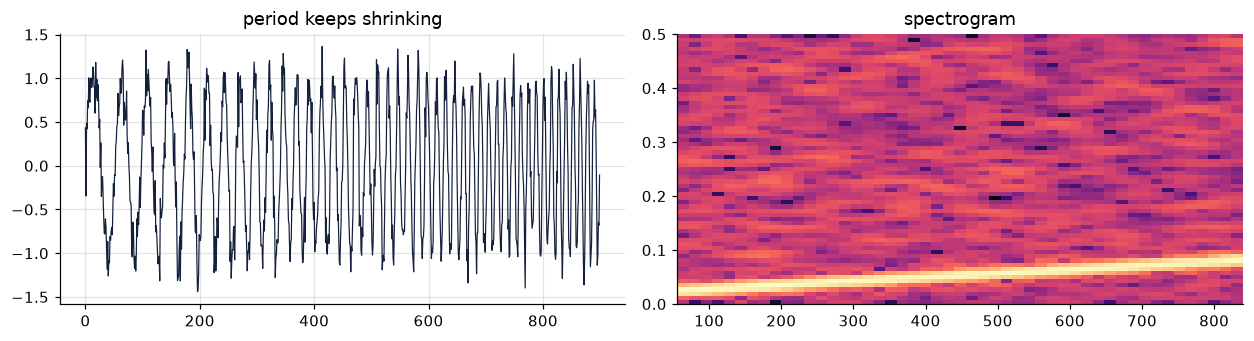

In [12]:
n = 900; t = np.arange(n)
chirp = np.sin(2*np.pi*np.cumsum(np.linspace(1/60, 1/12, n))) \
        + np.random.default_rng(13).normal(0, .18, n)

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.2))
ax[0].plot(chirp, color=INK, lw=.8); ax[0].set_title("period keeps shrinking")
ax[1].specgram(chirp, NFFT=128, noverlap=112, Fs=1.0, cmap="magma")
ax[1].set_title("spectrogram"); ax[1].grid(False)
plt.tight_layout()

---
## 4. Anomalies live in the remainder  ·  Lecture 1, slides 35 to 38

Four faults are injected below: two point spikes, one **contextual** anomaly (a perfectly
normal sales figure that lands on the wrong weekday), and eleven days of a frozen sensor.
Only one is easy to see in the raw plot. All four are obvious after decomposition.

In [13]:
rng = np.random.default_rng(5)
n = 336; t = np.arange(n)
trend  = 100 + 22 * (1 - np.exp(-t/130))
season = 9 * np.sin(2*np.pi*(t-2)/7)
y = trend + season + rng.normal(0, 1.4, n)

y[97]  += 15                                        # point spike, visible
y[231] += 14                                        # point spike, hidden by the trend
y[168]  = trend[168] + 9.5                          # CONTEXTUAL: right value, wrong weekday
y[270:281] = trend[270:281] + rng.normal(0, .4, 11) # COLLECTIVE: sensor froze
injected = sorted([97, 168, 231] + list(range(270, 281)))

s   = pd.Series(y)
r   = STL(s, period=7, robust=True, seasonal=15, trend=91).fit()
rem = s - r.seasonal - pd.Series(r.trend)

flagged : [97, 168, 231, 270, 273, 274, 276, 277, 280]
injected: [97, 168, 231, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280]


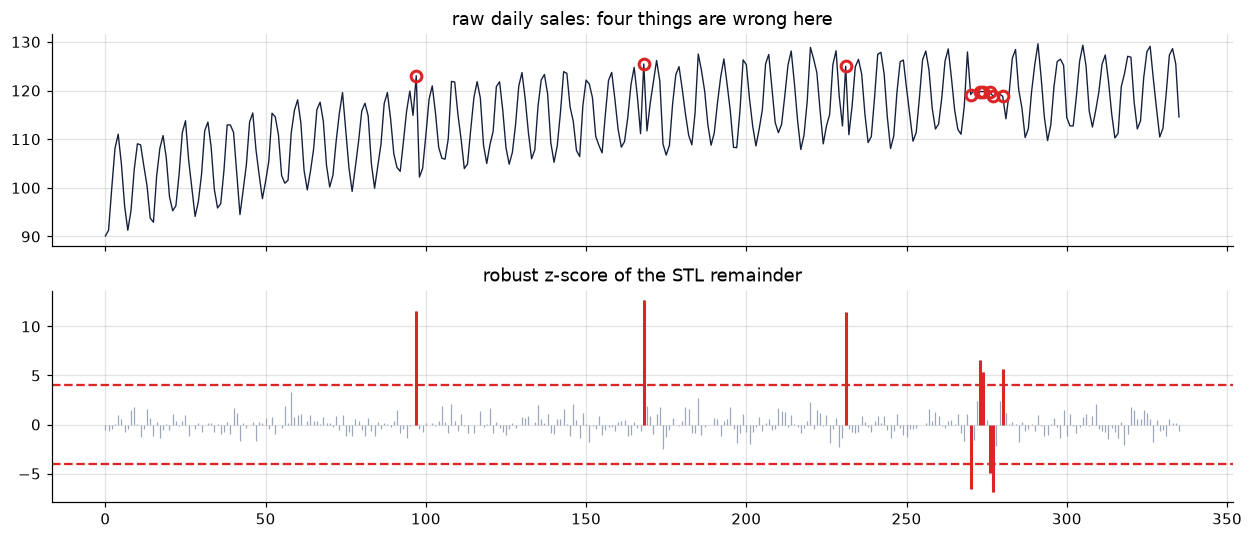

In [14]:
# Robust z-score: median and MAD, NOT mean and std.
# A single big outlier inflates the std, widening your own threshold and hiding itself.
# That failure mode is called *masking*.
z = (rem - rem.median()) / (1.4826 * np.median(np.abs(rem - rem.median())))
flag = np.abs(z) > 4

fig, ax = plt.subplots(2, 1, figsize=(11.5, 5), sharex=True)
ax[0].plot(t, y, color=INK, lw=.9)
ax[0].plot(t[flag], y[flag], "o", ms=7, mfc="none", mec=RED, mew=2)
ax[0].set_title("raw daily sales: four things are wrong here")
ax[1].vlines(t, 0, z, color="#9AA6BA", lw=.8)
ax[1].vlines(t[flag], 0, z[flag], color=RED, lw=2)
for k in (4, -4): ax[1].axhline(k, ls="--", color=RED)
ax[1].set_title("robust z-score of the STL remainder"); plt.tight_layout()

print("flagged :", sorted(t[flag].tolist()))
print("injected:", injected)

**Try it:** compute a plain z-score using `rem.mean()` and `rem.std()` instead, and see how
many of the eleven frozen-sensor days survive. That is masking in one line.

---
## 5. Stationarity and the treatment pipeline  ·  Lecture 1, slides 39 to 51

**Direction of the nulls, which everybody gets wrong:**

| Test | H0 | You want |
|---|---|---|
| ADF | there IS a unit root, so non-stationary | a **small** p |
| KPSS | the series IS stationary | a **large** p |
| Ljung-Box (lecture 2) | residuals ARE white noise | a **large** p |

In [15]:
import warnings
from statsmodels.tsa.stattools import adfuller, kpss

def report(x, name=""):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        p_adf  = adfuller(np.asarray(x, float), autolag="AIC")[1]
        p_kpss = kpss(np.asarray(x, float), regression="c", nlags="auto")[1]
    verdict = "STATIONARY" if p_adf < .05 else "not stationary"
    print(f"{name:26s} ADF p={p_adf:7.4f}   KPSS p={p_kpss:5.3f}   -> {verdict}")
    return p_adf

# The treatment, in the order that matters: variance, then trend, then season.
y  = np.log(air)                    # 1. stabilise the variance
d1 = y.diff().dropna()              # 2. remove the trend
d2 = d1.diff(12).dropna()           # 3. remove the season, m = 12

report(air, "1. raw")
report(y,   "2. log")
report(d1,  "3. log + diff")
report(d2,  "4. log + diff + seasdiff");

1. raw                     ADF p= 0.9919   KPSS p=0.010   -> not stationary
2. log                     ADF p= 0.4224   KPSS p=0.010   -> not stationary
3. log + diff              ADF p= 0.0711   KPSS p=0.100   -> not stationary
4. log + diff + seasdiff   ADF p= 0.0002   KPSS p=0.100   -> STATIONARY


Look at step 3. The trend is visibly gone and the p-value is still 0.07, because the
seasonality is still in there. **One difference is not a magic wand: you have to remove
every violation.**

### 5.1 Over-differencing

Differencing an already-stationary series injects noise. Stop at the smallest order whose
variance stops falling, and watch for a large negative ACF spike at lag 1.

In [16]:
stage = d2
for k in range(3):
    print(f"{k} extra difference(s): variance = {stage.var():.4f},"
          f"  lag-1 ACF = {acf(stage.values, 1)[1]:+.2f}")
    stage = stage.diff().dropna()

0 extra difference(s): variance = 0.0021,  lag-1 ACF = -0.34
1 extra difference(s): variance = 0.0057,  lag-1 ACF = -0.67
2 extra difference(s): variance = 0.0190,  lag-1 ACF = -0.78


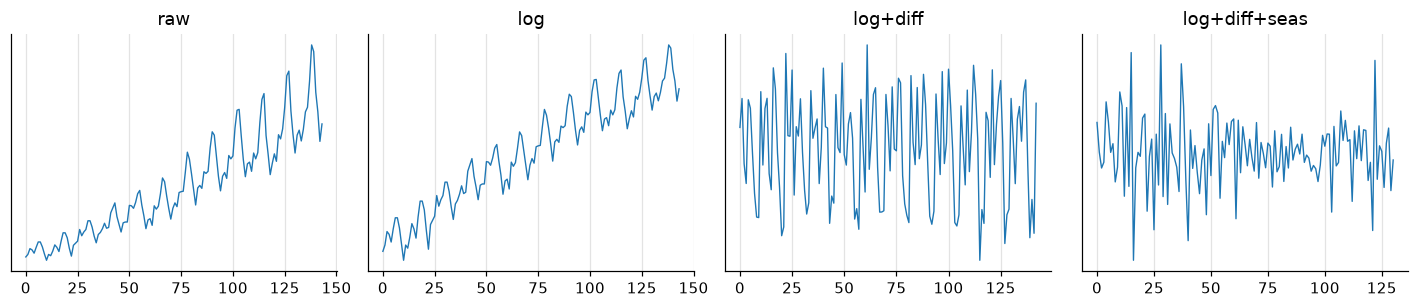

In [17]:
fig, ax = plt.subplots(1, 4, figsize=(13, 2.9))
for a, (v, lab) in zip(ax, [(air, "raw"), (y, "log"), (d1, "log+diff"), (d2, "log+diff+seas")]):
    a.plot(np.asarray(v), lw=.9); a.set_title(lab); a.set_yticks([])
plt.tight_layout()
# Shortcuts you are allowed to use, if pmdarima is installed:
#   from pmdarima.arima import ndiffs, nsdiffs
#   ndiffs(y), nsdiffs(y, m=12)

---
## 6. ACF, PACF and model signatures  ·  Lecture 2, slides 4 to 8

| Model | ACF | PACF |
|---|---|---|
| AR(p) | tails off | **cuts off after lag p** |
| MA(q) | **cuts off after lag q** | tails off |
| ARMA(p,q) | tails off | tails off |
| white noise | inside the band | inside the band |
| non-stationary | decays very slowly | |

AR is finite in *values*, MA is finite in *shocks*, and each is finite in the plot that
measures its own currency.

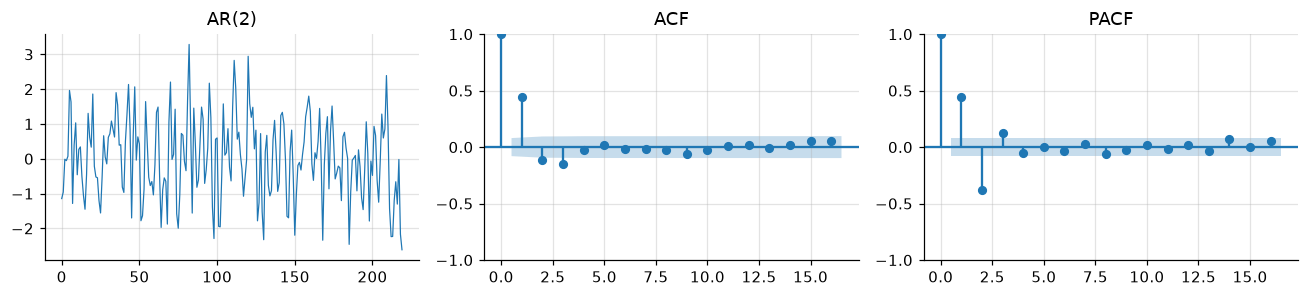

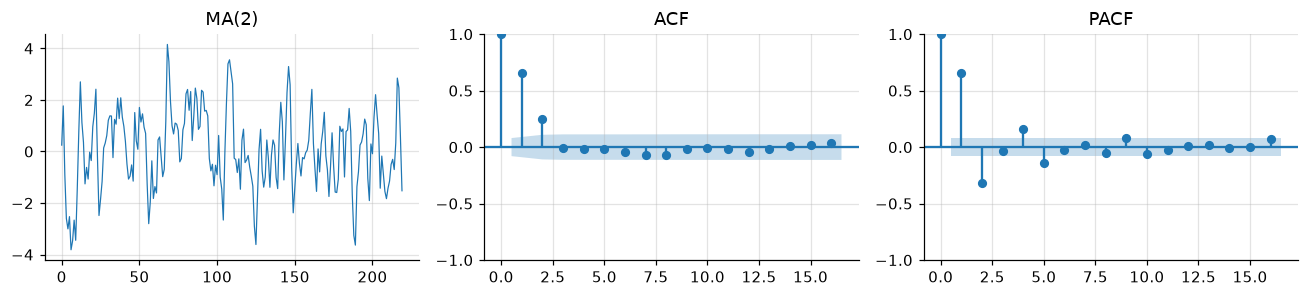

In [18]:
from statsmodels.graphics.tsaplots import plot_acf as sm_acf, plot_pacf as sm_pacf

def simulate_ar(phis, n=600, seed=1):
    e = np.random.default_rng(seed).normal(0, 1, n+100); x = np.zeros(n+100)
    for t in range(len(phis), n+100):
        x[t] = sum(p*x[t-i-1] for i, p in enumerate(phis)) + e[t]
    return x[100:]

def simulate_ma(ths, n=600, seed=2):
    e = np.random.default_rng(seed).normal(0, 1, n+100)
    return np.array([e[t] + sum(th*e[t-i-1] for i, th in enumerate(ths))
                     for t in range(len(ths), n+100)])[100:]

for x, name in [(simulate_ar([.6, -.35], seed=5), "AR(2)"),
                (simulate_ma([.8, .5],  seed=6), "MA(2)")]:
    fig, ax = plt.subplots(1, 3, figsize=(12, 2.8))
    ax[0].plot(x[:220], lw=.8); ax[0].set_title(name)
    sm_acf(x,  lags=16, ax=ax[1]); ax[1].set_title("ACF")
    sm_pacf(x, lags=16, ax=ax[2]); ax[2].set_title("PACF")
    plt.tight_layout(); plt.show()

---
## 7. Benchmarks and exponential smoothing  ·  Lecture 2, slides 11 to 14

If your model does not beat **seasonal naive**, it is not earning its complexity.

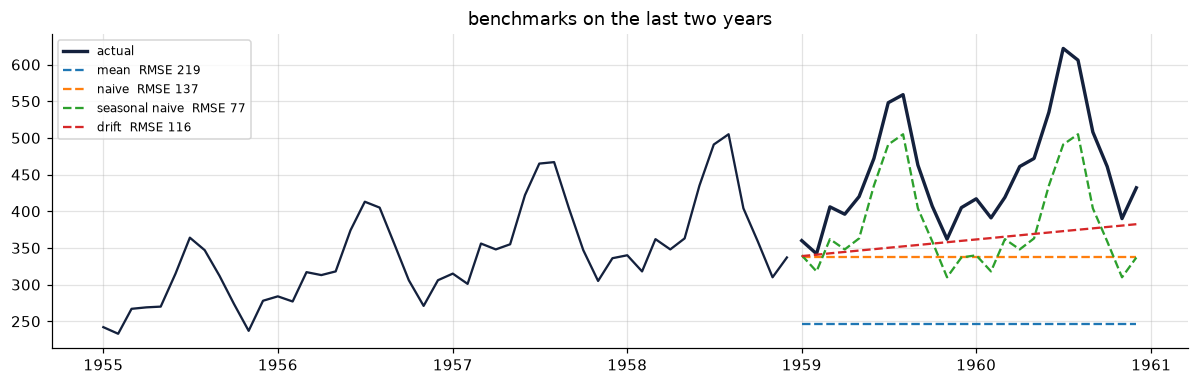

In [19]:
h = 24
train, test = air[:-h], air[-h:]

forecasts = {
    "mean":           np.full(h, train.mean()),
    "naive":          np.full(h, train.iloc[-1]),
    "seasonal naive": np.array([train.iloc[-12 + (i % 12)] for i in range(h)]),
    "drift":          train.iloc[-1] + (train.iloc[-1]-train.iloc[0])/(len(train)-1)
                      * np.arange(1, h+1),
}
def rmse(f, a=test.values): return float(np.sqrt(np.mean((f - a)**2)))
def mae (f, a=test.values): return float(np.mean(np.abs(f - a)))

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(train.index[-48:], train.values[-48:], color=INK)
ax.plot(test.index, test.values, color=INK, lw=2.2, label="actual")
for lab, f in forecasts.items():
    ax.plot(test.index, f, "--", label=f"{lab}  RMSE {rmse(f):.0f}")
ax.legend(fontsize=8); ax.set_title("benchmarks on the last two years"); plt.tight_layout()

In [20]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

models = {
    "simple (level)":              SimpleExpSmoothing(train).fit(),
    "Holt (level+trend)":          ExponentialSmoothing(train, trend="add").fit(),
    "Holt-Winters (+season)":      ExponentialSmoothing(train, trend="add", seasonal="mul",
                                                        seasonal_periods=12).fit(),
}
for lab, m in models.items():
    print(f"{lab:26s} RMSE {rmse(m.forecast(h).values):6.1f}   MAE {mae(m.forecast(h).values):6.1f}")
print(f"{'seasonal naive':26s} RMSE {rmse(forecasts['seasonal naive']):6.1f}")

simple (level)             RMSE  137.3   MAE  115.3
Holt (level+trend)         RMSE  115.7   MAE   91.6
Holt-Winters (+season)     RMSE   32.5   MAE   29.0
seasonal naive             RMSE   77.0


---
## 8. SARIMA, diagnostics and evaluation  ·  Lecture 2, slides 15 to 26

Everything section 5 derived becomes the specification: log data, `d=1`, `D=1`, `m=12`.
The ACF then supplies one MA term at lag 1 and one seasonal MA term at lag 12, giving the
classic **airline model** `SARIMA(0,1,1)(0,1,1)[12]`.

RMSE 18.6   MAPE 2.91%   AIC -441.3


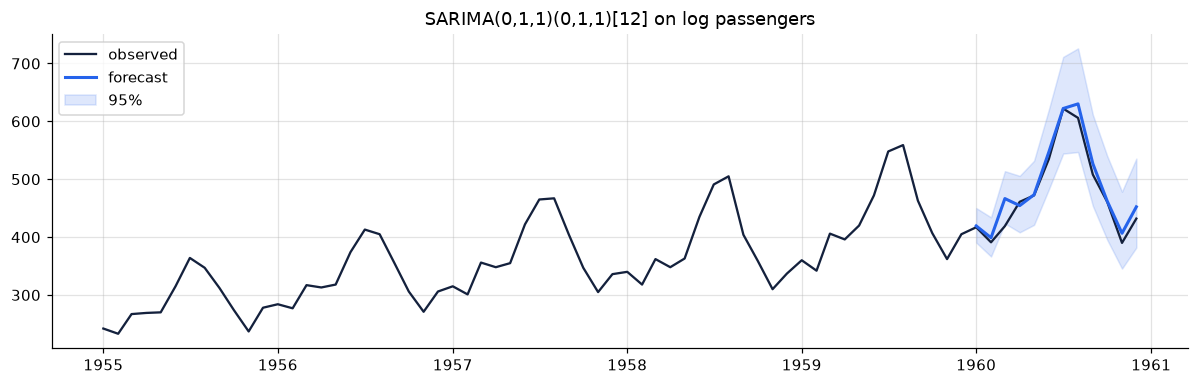

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings("ignore")

h = 12
tr_log, te = np.log(air[:-h]), air[-h:]
fit = SARIMAX(tr_log, order=(0,1,1), seasonal_order=(0,1,1,12)).fit(disp=False)

fc  = fit.get_forecast(h)
pt  = np.exp(fc.predicted_mean)                  # UNDO THE LOG before you measure anything
ci  = np.exp(fc.conf_int(alpha=.05))

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(air.index[-72:], air.values[-72:], color=INK, label="observed")
ax.plot(te.index, pt.values, color=BLUE, lw=2, label="forecast")
ax.fill_between(te.index, ci.iloc[:,0], ci.iloc[:,1], color=BLUE, alpha=.15, label="95%")
ax.legend(); ax.set_title("SARIMA(0,1,1)(0,1,1)[12] on log passengers"); plt.tight_layout()

mape = np.mean(np.abs((te.values - pt.values) / te.values)) * 100
print(f"RMSE {rmse(pt.values, te.values):.1f}   MAPE {mape:.2f}%   AIC {fit.aic:.1f}")

     lb_stat  lb_pvalue
12  6.846782    0.86757

Ljung-Box p = 0.868 -> residuals look like white noise, the model is done


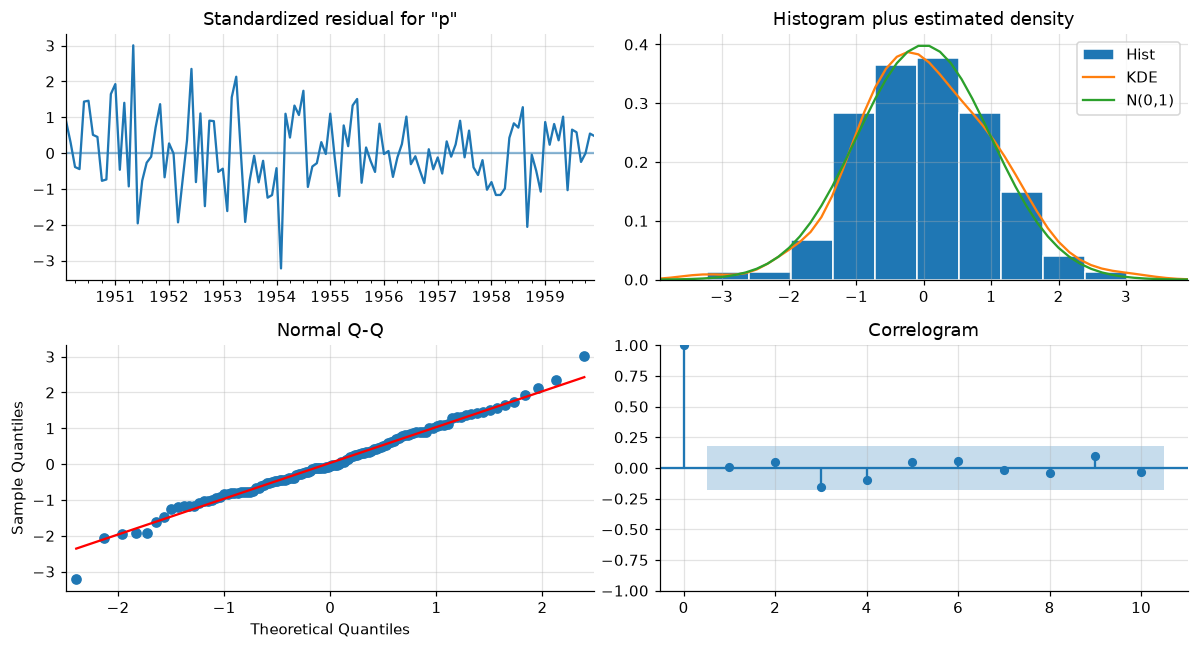

In [22]:
# Residual diagnostics. A LARGE Ljung-Box p-value is the good outcome.
from statsmodels.stats.diagnostic import acorr_ljungbox

fit.plot_diagnostics(figsize=(11, 6)); plt.tight_layout()
lb = acorr_ljungbox(fit.resid[13:], lags=[12], return_df=True)
print(lb)
print("\nLjung-Box p = %.3f -> %s"
      % (lb['lb_pvalue'].iloc[0],
         "residuals look like white noise, the model is done"
         if lb['lb_pvalue'].iloc[0] > .05 else "structure left, go back and re-identify"))

### 8.1 Never shuffle. Roll the origin forward.

A single hold-out gives you one number from one period. Rolling origin mimics how the model
is actually used, and gives you many.

In [23]:
def rolling_origin(series, order, seasonal_order, h=12, n_folds=5, start=96):
    errs = []
    for k in range(n_folds):
        cut = start + k*h
        if cut + h > len(series): break
        tr = np.log(series[:cut]); ac = series[cut:cut+h]
        m  = SARIMAX(tr, order=order, seasonal_order=seasonal_order).fit(disp=False)
        f  = np.exp(m.get_forecast(h).predicted_mean.values)
        errs.append(dict(fold=k, train_end=str(series.index[cut-1].date()),
                         rmse=rmse(f, ac.values), mae=mae(f, ac.values)))
    return pd.DataFrame(errs)

cv = rolling_origin(air, (0,1,1), (0,1,1,12))
display(cv)
print("mean RMSE over folds: %.1f  (a single split gave %.1f)"
      % (cv.rmse.mean(), rmse(pt.values, te.values)))

,fold,train_end,rmse,mae
0,0,1956-12-01,8.192412,6.359071
1,1,1957-12-01,30.112512,27.615279
2,2,1958-12-01,31.571375,29.386218
3,3,1959-12-01,18.599303,13.269054


mean RMSE over folds: 22.1  (a single split gave 18.6)


In [24]:
# AIC over a grid. Read a shortlist off the ACF/PACF, then let AIC arbitrate.
y_all = np.log(air)
rows = []
for p in range(3):
    for q in range(3):
        try:
            m = SARIMAX(y_all, order=(p,1,q), seasonal_order=(0,1,1,12)).fit(disp=False)
            rows.append(dict(p=p, q=q, aic=round(m.aic, 2), bic=round(m.bic, 2)))
        except Exception as e:
            rows.append(dict(p=p, q=q, aic=np.nan, bic=np.nan))
grid = pd.DataFrame(rows).pivot(index="p", columns="q", values="aic")
display(grid)
print("lowest AIC at (p,q) =", np.unravel_index(np.nanargmin(grid.values), grid.shape))

q,0,1,2
p,,,
0,-467.55,-483.39,-481.61
1,-481.48,-481.89,-479.40
2,-480.02,-481.95,-479.57


lowest AIC at (p,q) = (np.int64(0), np.int64(1))


### 8.2 The metric encodes what you think a bad forecast is

Two models with **identical MAE**. RMSE tells them apart because it squares first.

In [25]:
n = 48
actual = 40 + 16*np.sin(2*np.pi*np.arange(n)/24)
eA = np.random.default_rng(4).choice([-1., 1.], n)          # many small errors
eB = np.zeros(n); eB[12] = n                                # one large error
for lab, e in [("A: many small", eA), ("B: one big", eB)]:
    print(f"{lab:16s} MAE {np.mean(np.abs(e)):.2f}   RMSE {np.sqrt(np.mean(e**2)):.2f}")

# And why MAPE is dangerous near zero:
small = np.array([2.0, 1.2, 0.8]); err = 2.0
print("\nMAPE of a constant 2-unit error on values", small, "=",
      np.round(np.abs(err/small)*100, 0), "%")

A: many small    MAE 1.00   RMSE 1.00
B: one big       MAE 1.00   RMSE 6.93

MAPE of a constant 2-unit error on values [2.  1.2 0.8] = [100. 167. 250.] %


---
## 9. Similarity  ·  Lecture 2, slides 32 to 38

### 9.1 z-normalise every window, separately

Two identical shapes at different levels and scales are unrelated to Euclidean distance
until you z-normalise. Note the cost: z-normalisation deliberately destroys level and
amplitude, which matters when amplitude *is* the fault you are hunting.

raw Euclidean distance        : 355.6
z-normalised distance         : 0.0000


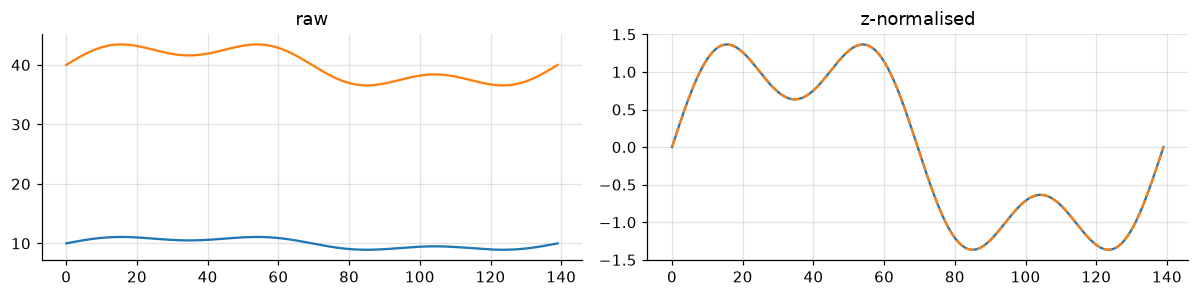

In [26]:
def znorm(x, axis=-1):
    m = np.mean(x, axis=axis, keepdims=True)
    s = np.std(x,  axis=axis, keepdims=True)
    return (x - m) / np.where(s < 1e-9, 1.0, s)

t = np.linspace(0, 1, 140)
shape = np.sin(2*np.pi*t) + .5*np.sin(6*np.pi*t)
A, B = shape*1.0 + 10, shape*3.2 + 40

print("raw Euclidean distance        : %.1f" % np.linalg.norm(A - B))
print("z-normalised distance         : %.4f" % np.linalg.norm(znorm(A) - znorm(B)))

fig, ax = plt.subplots(1, 2, figsize=(11, 2.8))
ax[0].plot(A); ax[0].plot(B); ax[0].set_title("raw")
ax[1].plot(znorm(A)); ax[1].plot(znorm(B), "--"); ax[1].set_title("z-normalised")
plt.tight_layout()

### 9.2 Dynamic time warping

DTW is a shortest-path problem: the same dynamic programming you already know from edit
distance. The **Sakoe-Chiba band** both improves the answer and cuts the cost from
`O(nm)` to `O(nw)`.

Euclidean 4.940   vs   DTW 0.553


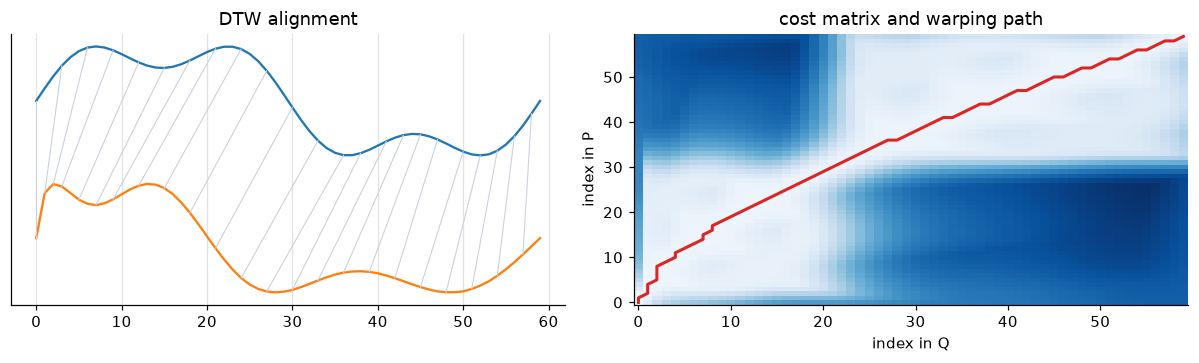

In [27]:
def dtw(A, B, band=None):
    "Returns (distance, cumulative cost matrix, warping path)."
    n, m = len(A), len(B)
    cost = (A[:, None] - B[None, :])**2
    D = np.full((n+1, m+1), np.inf); D[0, 0] = 0
    for i in range(1, n+1):
        lo, hi = (1, m) if band is None else (max(1, i-band), min(m, i+band))
        for j in range(lo, hi+1):
            D[i, j] = cost[i-1, j-1] + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    # backtrack
    i, j, path = n-1, m-1, [(n-1, m-1)]
    Dm = D[1:, 1:]
    while i > 0 or j > 0:
        if   i == 0: j -= 1
        elif j == 0: i -= 1
        else:
            k = int(np.argmin([Dm[i-1, j-1], Dm[i-1, j], Dm[i, j-1]]))
            i, j = [(i-1, j-1), (i-1, j), (i, j-1)][k]
        path.append((i, j))
    return np.sqrt(Dm[n-1, m-1]), Dm, np.array(path[::-1])

t = np.linspace(0, 1, 60)
P = np.sin(2*np.pi*t) + .4*np.sin(6*np.pi*t)
Q = np.interp(t, np.clip(t**1.55, 0, 1), P)          # same shape, warped in time

d_euclid = np.linalg.norm(P - Q)
d_dtw, D, path = dtw(P, Q)
print("Euclidean %.3f   vs   DTW %.3f" % (d_euclid, d_dtw))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(P); ax[0].plot(Q - 2.5)
for i, j in path[::3]:
    ax[0].plot([i, j], [P[i], Q[j]-2.5], color="#C9D1DC", lw=.7)
ax[0].set_title("DTW alignment"); ax[0].set_yticks([])
ax[1].imshow(np.log1p(D), origin="lower", cmap="Blues", aspect="auto")
ax[1].plot(path[:,1], path[:,0], color=RED, lw=2)
ax[1].set_xlabel("index in Q"); ax[1].set_ylabel("index in P")
ax[1].set_title("cost matrix and warping path"); ax[1].grid(False)
plt.tight_layout()

### 9.3 PAA and SAX

PAA averages within equal segments and **lower bounds** the true Euclidean distance, so you
can prune with it and still get an exact answer. SAX turns each segment into a letter, which
makes every string algorithm available for time series.

PAA (8 segments): [ 0.82  1.19  0.49  0.64 -0.32 -1.68 -1.   -0.15]
SAX word        : ddccbaab


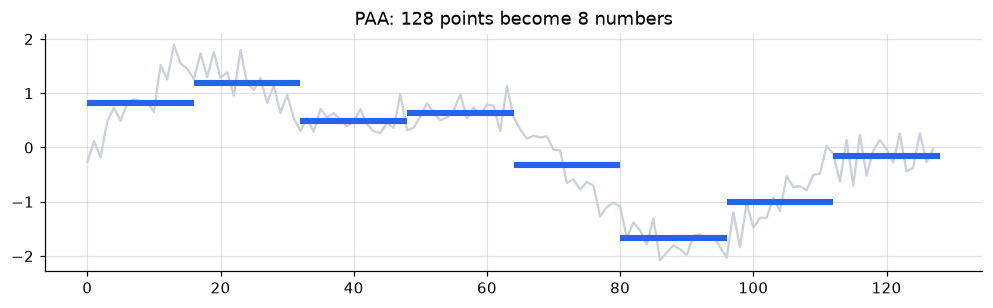

In [28]:
from scipy.stats import norm

def paa(x, w):
    return znorm(np.asarray(x, float)).reshape(w, -1).mean(1)

def sax(x, w, alphabet=4):
    cuts = norm.ppf(np.linspace(0, 1, alphabet+1)[1:-1])
    letters = np.array(list("abcdefgh"))[:alphabet]
    return "".join(letters[np.searchsorted(cuts, paa(x, w))])

x = np.sin(2*np.pi*np.linspace(0,1,128)) + .5*np.sin(5*np.pi*np.linspace(0,1,128)) \
    + np.random.default_rng(9).normal(0, .18, 128)
print("PAA (8 segments):", np.round(paa(x, 8), 2))
print("SAX word        :", sax(x, 8))

plt.figure(figsize=(11, 2.8))
plt.plot(znorm(x), color="#C9D1DC")
for i, v in enumerate(paa(x, 8)):
    plt.hlines(v, i*16, (i+1)*16, color=BLUE, lw=4)
plt.title("PAA: 128 points become 8 numbers");

---
## 10. Motifs, discords and the matrix profile  ·  Lecture 2, slides 39 to 46

For every window of length `m`, find the distance to its nearest neighbour **elsewhere** in
the series. That vector is the matrix profile.

* its **minimum** is the top **motif** pair, the most conserved shape in the data
* its **maximum** is the top **discord**, the most unusual window

One parameter, no labels, no threshold, no model of "normal".

The implementation below is the brute-force `O(n^2 m)` version, written out so you can see
exactly what it does. `stumpy` does the same thing in `O(n^2)` and is used automatically if
it is installed.

In [29]:
def subsequences(x, m):
    return np.lib.stride_tricks.sliding_window_view(np.asarray(x, float), m)

def distance_profile(x, m, i):
    "z-normalised Euclidean distance from window i to every window."
    S = znorm(subsequences(x, m))
    return np.sqrt(np.maximum(((S - S[i])**2).sum(1), 0))

def matrix_profile(x, m, exclusion=None):
    # Nearest non-trivial neighbour distance and index, for every window.
    # The exclusion zone is the detail that makes this work: windows starting at i and
    # i+1 share m-1 of their m points, so without it every window is its own best match.
    S = znorm(subsequences(x, m)); n = len(S)
    excl = int(np.ceil(m/4)) if exclusion is None else exclusion
    mp  = np.empty(n); mpi = np.empty(n, dtype=int)
    for i in range(n):
        d = np.sqrt(np.maximum(((S - S[i])**2).sum(1), 0))
        d[max(0, i-excl): min(n, i+excl+1)] = np.inf
        mpi[i] = int(np.argmin(d)); mp[i] = d[mpi[i]]
    return mp, mpi

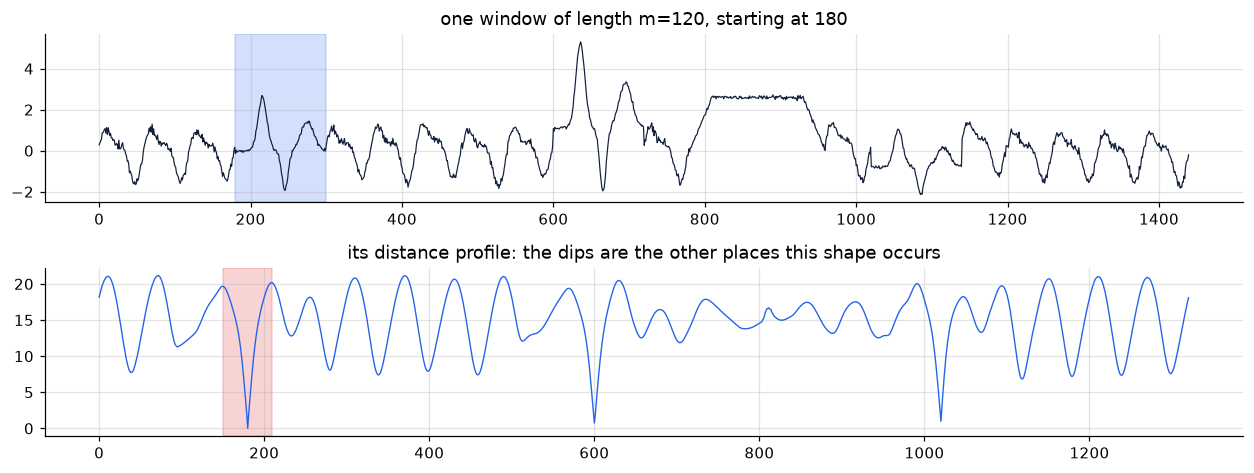

In [30]:
def demo_series(seed=17):
    "Repeated background beats, three copies of a distinctive motif, one unique anomaly."
    rng = np.random.default_rng(seed)
    b, nb, m = 60, 24, 120
    u = np.linspace(0, 1, b, endpoint=False)
    beat = np.sin(2*np.pi*u) + .45*np.sin(4*np.pi*u + .7)
    beats = [beat*rng.uniform(.88, 1.12) + rng.normal(0, .10, b) + rng.uniform(-.25, .25)
             for _ in range(nb)]
    v = np.linspace(0, 1, m)
    motif = (np.exp(-((v-.30)/.07)**2)*2.6 - np.exp(-((v-.55)/.05)**2)*1.9
             + np.exp(-((v-.80)/.10)**2)*1.4)
    for k, (amp, off) in zip([3, 10, 17], [(1.0, 0.0), (1.6, 1.1), (0.7, -0.8)]):
        seg = motif*amp + off + rng.normal(0, .05, m)
        beats[k], beats[k+1] = seg[:b], seg[b:]
    flat = np.concatenate([np.linspace(0, 2.6, 30), np.full(120, 2.6),
                           np.linspace(2.6, 0, 30)]) + rng.normal(0, .05, 180)
    beats[13], beats[14], beats[15] = flat[:b], flat[b:2*b], flat[2*b:]
    return np.concatenate(beats), m

x, m = demo_series()

# Step 1 and 2: one window, and its distance profile.
i0 = 180
dp = distance_profile(x, m, i0)
fig, ax = plt.subplots(2, 1, figsize=(11.5, 4.4))
ax[0].plot(x, color=INK, lw=.8); ax[0].axvspan(i0, i0+m, color=BLUE, alpha=.2)
ax[0].set_title(f"one window of length m={m}, starting at {i0}")
ax[1].plot(dp, color=BLUE, lw=.9); ax[1].axvspan(i0-m//4, i0+m//4, color=RED, alpha=.2)
ax[1].set_title("its distance profile: the dips are the other places this shape occurs")
plt.tight_layout()

stumpy not installed, using the brute-force implementation above
top motif  : windows at 180 and 600, distance 0.73
top discord: window at 812, nearest neighbour 13.47 away


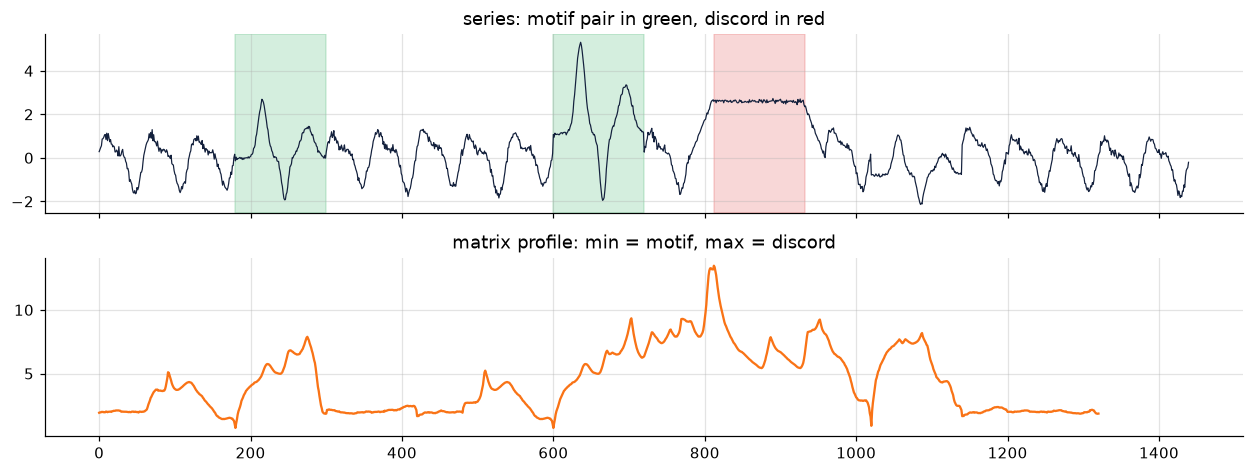

In [31]:
# Step 3: repeat for every window, keep the minimum. That is the matrix profile.
try:
    import stumpy
    out = stumpy.stump(x, m)
    mp, mpi = out[:, 0].astype(float), out[:, 1].astype(int)
    print("using stumpy")
except ImportError:
    mp, mpi = matrix_profile(x, m)
    print("stumpy not installed, using the brute-force implementation above")

i_motif = int(np.argmin(mp)); j_motif = int(mpi[i_motif])
i_disc  = int(np.argmax(mp))
print(f"top motif  : windows at {i_motif} and {j_motif}, distance {mp[i_motif]:.2f}")
print(f"top discord: window at {i_disc}, nearest neighbour {mp[i_disc]:.2f} away")

fig, ax = plt.subplots(2, 1, figsize=(11.5, 4.4), sharex=True)
ax[0].plot(x, color=INK, lw=.8)
for st, c in [(i_motif, GREEN), (j_motif, GREEN), (i_disc, RED)]:
    ax[0].axvspan(st, st+m, color=c, alpha=.18)
ax[0].set_title("series: motif pair in green, discord in red")
ax[1].plot(mp, color=ORANGE); ax[1].set_title("matrix profile: min = motif, max = discord")
plt.tight_layout()

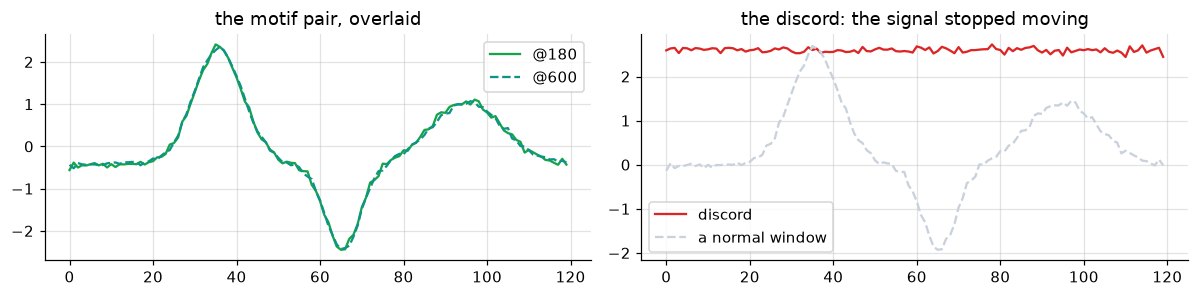

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(11, 2.8))
ax[0].plot(znorm(x[i_motif:i_motif+m]), color=GREEN, label=f"@{i_motif}")
ax[0].plot(znorm(x[j_motif:j_motif+m]), "--", color=TEAL, label=f"@{j_motif}")
ax[0].legend(); ax[0].set_title("the motif pair, overlaid")
ax[1].plot(x[i_disc:i_disc+m], color=RED, label="discord")
ax[1].plot(x[i_motif:i_motif+m], color="#C9D1DC", ls="--", label="a normal window")
ax[1].legend(); ax[1].set_title("the discord: the signal stopped moving")
plt.tight_layout()
# Nobody told the algorithm what a motif or an anomaly looks like. It only measured, for
# each window, how far away its nearest neighbour is.

### 10.1 Semantic segmentation from the matrix profile *index*

Throw away the distances and keep only *which window matched which*. Draw an arc between
each matched pair. Very few arcs cross a regime change, because windows only match others
of their own kind. Count the crossings and take the minimum: that is **FLUSS**.

true change at 600, detected at 591


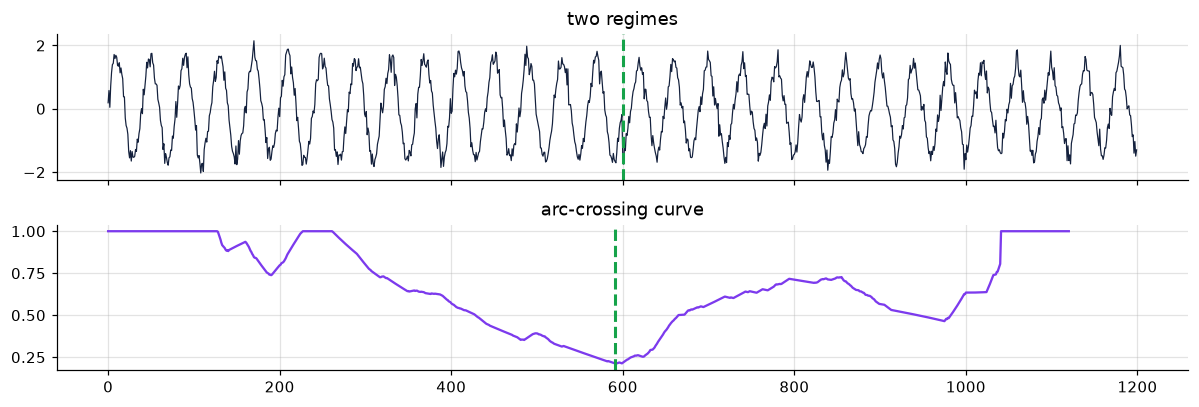

In [33]:
rng = np.random.default_rng(6)
seg1 = np.tile(np.sin(np.linspace(0, 2*np.pi, 40)), 15) * 1.6
seg2 = np.tile(np.concatenate([np.linspace(-1,1,20), np.linspace(1,-1,20)]), 15) * 1.6
z = np.concatenate([seg1, seg2]) + rng.normal(0, .18, len(seg1)+len(seg2))
mw = 80
_, idx = matrix_profile(z, mw)

n = len(idx); cross = np.zeros(n)
for i, j in enumerate(idx):
    cross[min(i,j):max(i,j)] += 1
ideal = 2*np.arange(n)*(n-np.arange(n))/n
cac = np.clip(cross/np.where(ideal < 1e-9, 1, ideal), 0, 1)
cac[:mw] = 1; cac[-mw:] = 1

fig, ax = plt.subplots(2, 1, figsize=(11, 3.8), sharex=True)
ax[0].plot(z, color=INK, lw=.8); ax[0].axvline(len(seg1), color=GREEN, ls="--", lw=2)
ax[0].set_title("two regimes")
ax[1].plot(cac, color=PURPLE); ax[1].axvline(np.argmin(cac), color=GREEN, ls="--", lw=2)
ax[1].set_title("arc-crossing curve"); plt.tight_layout()
print("true change at %d, detected at %d" % (len(seg1), np.argmin(cac)))

---
## Exercises

**Lecture 1**

1. Load a series of your own with at least five years of monthly data. Plot it and write two
   sentences describing its components.
2. Run `STL` with and without `robust=True`. Where do the two trends differ, and why?
3. Reproduce section 5 on your series: report ADF and KPSS after each of log, difference and
   seasonal difference.
4. Inject three artificial anomalies into your series. Can the robust z-score on the STL
   remainder find all three? What threshold did you need? Now repeat with a plain
   mean-and-standard-deviation z-score and explain what changed.

**Lecture 2**

5. Fit seasonal naive, Holt-Winters and `SARIMAX` to your series. Report RMSE under
   **rolling-origin** evaluation, not a single split.
6. Run Ljung-Box on your best model's residuals. If it fails, say what you would change and
   why.
7. Compute a matrix profile over a long sensor or activity series. Plot the top motif pair
   and the top discord. Do they mean anything in the real world?
8. Compare Euclidean and DTW nearest-neighbour classification on a UCR archive dataset. Tune
   the DTW warping window and report both.

**Think about**

9. Why can an AR(1) be written as an MA of infinite order only when `|phi| < 1`?
10. Why does DTW break the triangle inequality? Construct three series that demonstrate it.
11. The matrix profile finds the *single* most unusual window. How would you find the top ten
    anomalies without getting ten overlapping copies of the same one?

---
*Hyndman & Athanasopoulos, "Forecasting: Principles and Practice", free at otexts.com/fpp3.
The Matrix Profile papers by Yeh, Zhu, Mueen and Keogh. The UCR Time Series Archive.*